In [17]:
import matplotlib.image as image
import matplotlib.pyplot as plt
import numpy as np
import time
from numba import jit, cuda

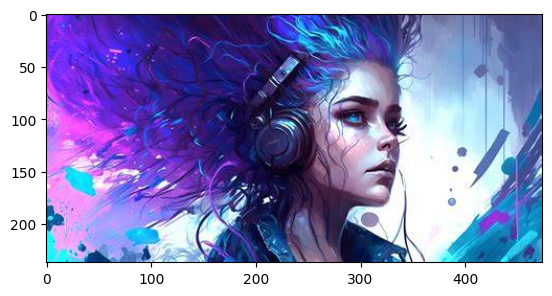

In [18]:
with open('./a.jpg', 'rb') as f:
    img = image.imread(f)
plt.imshow(img)
plt.show()

# 1D Conversion

In [19]:
@cuda.jit
def grayscale_kernel(input_img, output_img):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    g = np.uint8((input_img[tidx, 0] + input_img[tidx, 1] + input_img[tidx, 2]) / 3)
    output_img[tidx, 0] = output_img[tidx, 1] = output_img[tidx, 2] = g

original_shape = img.shape
img_flat = img.reshape(-1, 3).astype(np.uint8)

d_img = cuda.to_device(img_flat)
d_grayscale_img = cuda.device_array(
    img_flat.shape,
    dtype=np.uint8
)
pixelCount = img_flat.shape[0]
blockSize = 256
gridSize = (pixelCount + blockSize - 1) // blockSize
start = time.time()
grayscale_kernel[gridSize, blockSize](d_img, d_grayscale_img)
cuda.synchronize()
end = time.time()
grayscale_img = d_grayscale_img.copy_to_host()
print(f"GPU time: {end - start:.6f} seconds")

GPU time: 0.098543 seconds


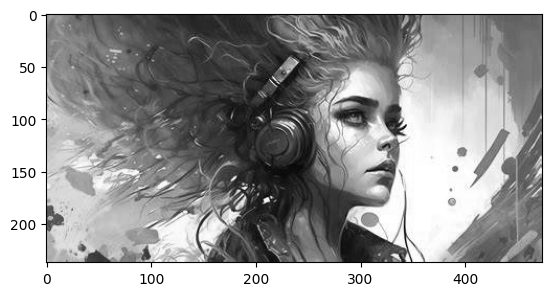

In [20]:
plt.imshow(grayscale_img.reshape(original_shape))

Block Size:    1 | Grid Size:   112338 | Average Time: 0.8799 ms
Block Size:    2 | Grid Size:    56169 | Average Time: 0.4418 ms
Block Size:    4 | Grid Size:    28085 | Average Time: 0.2262 ms
Block Size:    8 | Grid Size:    14043 | Average Time: 0.1160 ms
Block Size:   16 | Grid Size:     7022 | Average Time: 0.0617 ms
Block Size:   32 | Grid Size:     3511 | Average Time: 0.0428 ms
Block Size:   64 | Grid Size:     1756 | Average Time: 0.0410 ms
Block Size:  128 | Grid Size:      878 | Average Time: 0.0413 ms
Block Size:  256 | Grid Size:      439 | Average Time: 0.0412 ms
Block Size:  512 | Grid Size:      220 | Average Time: 0.0461 ms
Block Size: 1024 | Grid Size:      110 | Average Time: 0.0469 ms


/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 110 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


Text(0.5, 1.0, 'CUDA Grayscale: Block Size vs Execution Time')

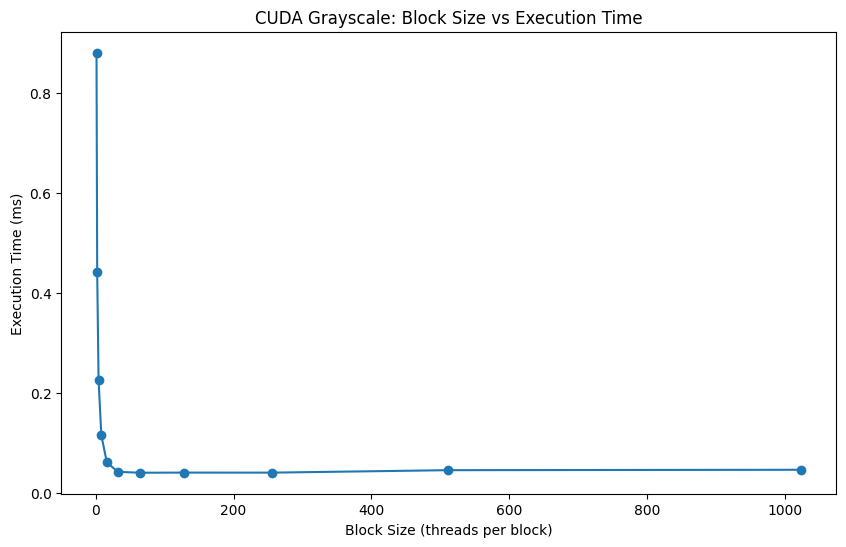

In [21]:
# Different block sizes to test
block_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]

times_1D = []

# Number of measurements for each block size
num_runs = 20


# Warm-up CUDA JIT compilation
blockSize = 256
gridSize = (pixelCount + blockSize - 1) // blockSize

grayscale_kernel[gridSize, blockSize](
    d_img,
    d_grayscale_img
)

cuda.synchronize()

# Benchmark
for blockSize in block_sizes:

    gridSize = (pixelCount + blockSize - 1) // blockSize

    # Warm up this configuration
    grayscale_kernel[gridSize, blockSize](
        d_img,
        d_grayscale_img
    )
    cuda.synchronize()

    start = time.time()

    for _ in range(num_runs):
        grayscale_kernel[gridSize, blockSize](
            d_img,
            d_grayscale_img
        )

    cuda.synchronize()

    end = time.time()

    # Average execution time
    avg_time = (end - start) / num_runs

    times_1D.append(avg_time)

    print(
        f"Block Size: {blockSize:4d} | "
        f"Grid Size: {gridSize:8d} | "
        f"Average Time: {avg_time * 1000:.4f} ms"
    )


# Copy final result back to CPU
grayscale_img = d_grayscale_img.copy_to_host()
grayscale_img = grayscale_img.reshape(original_shape)


# Plot
plt.figure(figsize=(10, 6))

plt.plot(
    block_sizes,
    np.array(times_1D) * 1000,
    marker="o"
)

plt.xlabel("Block Size (threads per block)")
plt.ylabel("Execution Time (ms)")
plt.title("CUDA Grayscale: Block Size vs Execution Time")

# 2D Conversion

In [22]:
@cuda.jit
def grayscale_kernel(input_img, output_img):
    x, y = cuda.grid(2)
    height = input_img.shape[0]
    width = input_img.shape[1]

    if x < width and y < height:
        g = (
            int(input_img[y, x, 0])
            + int(input_img[y, x, 1])
            + int(input_img[y, x, 2])
        ) // 3

        output_img[y, x, 0] = g
        output_img[y, x, 1] = g
        output_img[y, x, 2] = g


input_img = img.astype(np.uint8)
height, width, channels = input_img.shape
d_img = cuda.to_device(input_img)
d_grayscale_img = cuda.device_array(
    input_img.shape,
    dtype=np.uint8
)

blockSize = (8, 8)
gridSize = (32, 32)

start = time.time()
grayscale_kernel[gridSize, blockSize](d_img, d_grayscale_img)
cuda.synchronize()
end = time.time()
grayscale_img = d_grayscale_img.copy_to_host()
print(f"GPU time: {end - start:.6f} seconds")

GPU time: 0.129355 seconds


/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 16 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


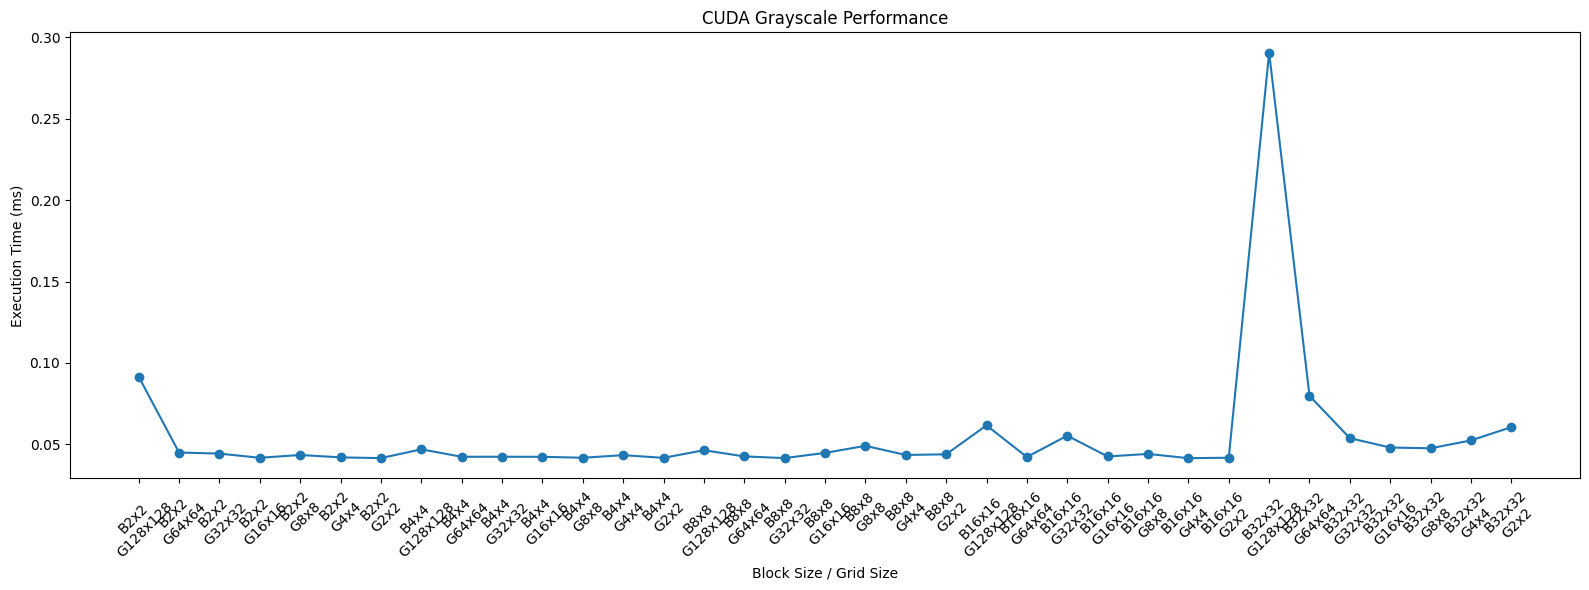

In [28]:
# Different block sizes to test
block_sizes = [(2,2), (4,4), (8, 8), (16, 16), (32, 32)]
grid_sizes = [(128, 128), (64, 64), (32, 32), (16, 16), (8, 8), (4, 4), (2, 2)]
times = []

# Number of measurements for each block size
num_runs = len(block_sizes) * len(grid_sizes)

grayscale_kernel[gridSize[0], blockSize[0]](
    d_img,
    d_grayscale_img
)

cuda.synchronize()

labels = []
times_2D = []

for blockSize in block_sizes:
    for gridSize in grid_sizes:

        grayscale_kernel[gridSize, blockSize](
            d_img,
            d_grayscale_img
        )
        cuda.synchronize()

        start = time.time()

        for _ in range(num_runs):
            grayscale_kernel[gridSize, blockSize](
                d_img,
                d_grayscale_img
            )

        cuda.synchronize()

        end = time.time()

        avg_time = (end - start) / num_runs
        times_2D.append(avg_time)

        labels.append(
            f"B{blockSize[0]}x{blockSize[1]}\n"
            f"G{gridSize[0]}x{gridSize[1]}"
        )
plt.figure(figsize=(16, 6))

plt.plot(
    range(len(times_2D)),
    np.array(times_2D) * 1000,
    marker="o"
)

plt.xticks(
    range(len(labels)),
    labels,
    rotation=45
)

plt.xlabel("Block Size / Grid Size")
plt.ylabel("Execution Time (ms)")
plt.title("CUDA Grayscale Performance")

plt.tight_layout()
plt.show()

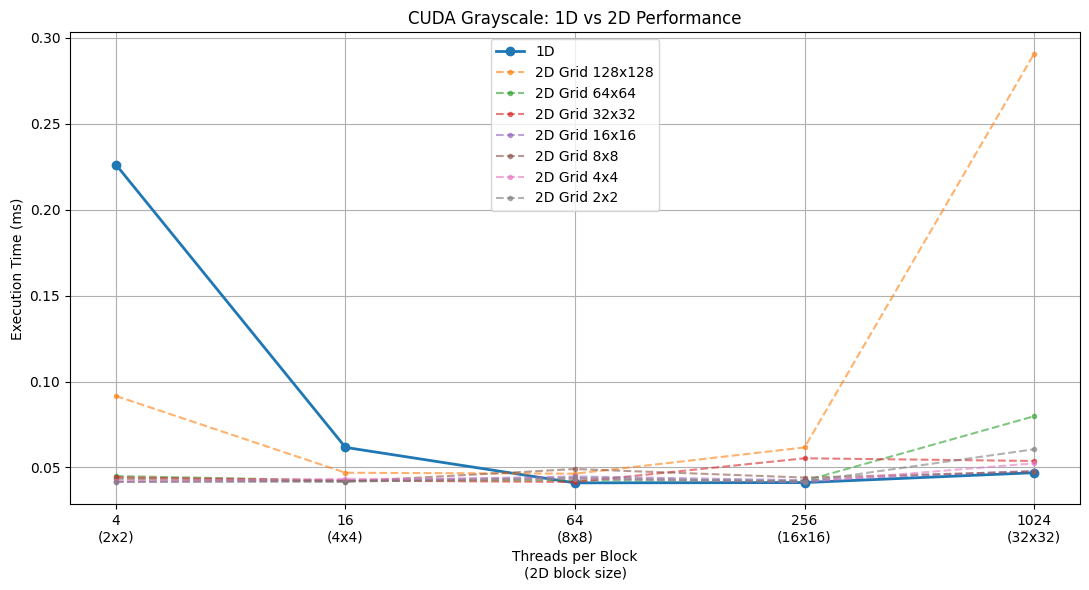

In [29]:
import numpy as np
import matplotlib.pyplot as plt

block_sizes_1D = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]

block_sizes_2D = [
    (2, 2),
    (4, 4),
    (8, 8),
    (16, 16),
    (32, 32)
]

grid_sizes = [
    (128, 128),
    (64, 64),
    (32, 32),
    (16, 16),
    (8, 8),
    (4, 4),
    (2, 2)
]

# Equivalent number of threads/block
threads_2D = [x * y for x, y in block_sizes_2D]
# [4, 16, 64, 256, 1024]


# ----------------------------
# Select matching 1D results
# ----------------------------
times_1D_matching = [
    times_1D[block_sizes_1D.index(t)]
    for t in threads_2D
]


# ----------------------------
# Reshape 2D results
#
# 5 block sizes × 7 grid sizes
# ----------------------------
times_2D_matrix = np.array(times_2D).reshape(
    len(block_sizes_2D),
    len(grid_sizes)
)


# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(11, 6))

# 1D results
plt.plot(
    threads_2D,
    np.array(times_1D_matching) * 1000,
    marker="o",
    linewidth=2,
    label="1D"
)


# 2D results: keep ALL grid-size measurements
for j, grid in enumerate(grid_sizes):
    plt.plot(
        threads_2D,
        times_2D_matrix[:, j] * 1000,
        marker=".",
        linestyle="--",
        alpha=0.6,
        label=f"2D Grid {grid[0]}x{grid[1]}"
    )


plt.xscale("log", base=2)

plt.xticks(
    threads_2D,
    [
        "4\n(2x2)",
        "16\n(4x4)",
        "64\n(8x8)",
        "256\n(16x16)",
        "1024\n(32x32)"
    ]
)

plt.xlabel("Threads per Block\n(2D block size)")
plt.ylabel("Execution Time (ms)")

plt.title("CUDA Grayscale: 1D vs 2D Performance")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()